In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [2]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

In [3]:
np.random.seed(42)
# %10 eksik veri ekleme
missing_mask = np.random.rand(*X.shape) < 0.1
X_dirty = X.mask(missing_mask)

In [4]:
X_clean = X_dirty.fillna(X_dirty.mean())

In [5]:
scaler_std = StandardScaler()
X_standard = scaler_std.fit_transform(X_clean)

In [6]:
scaler_norm = MinMaxScaler()
X_normal = scaler_norm.fit_transform(X_clean)

In [7]:
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_standard, y, test_size=0.3, random_state=42
)

In [8]:
X_train_n, X_test_n, _, _ = train_test_split(
    X_normal, y, test_size=0.3, random_state=42
)

In [9]:
model_s = SVC(kernel='rbf', C=1, gamma='scale')
model_s.fit(X_train_s, y_train)
y_pred_s = model_s.predict(X_test_s)


In [10]:
model_n = SVC(kernel='rbf', C=1, gamma='scale')
model_n.fit(X_train_n, y_train)
y_pred_n = model_n.predict(X_test_n)

In [11]:
print("Standardizasyon Accuracy:", accuracy_score(y_test, y_pred_s))
print(classification_report(y_test, y_pred_s))

print("\nNormalizasyon Accuracy:", accuracy_score(y_test, y_pred_n))
print(classification_report(y_test, y_pred_n))

Standardizasyon Accuracy: 0.9555555555555556
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.92      0.92      0.92        13
           2       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.95      0.95      0.95        45
weighted avg       0.96      0.96      0.96        45


Normalizasyon Accuracy: 0.9555555555555556
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.92      0.92      0.92        13
           2       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.95      0.95      0.95        45
weighted avg       0.96      0.96      0.96        45



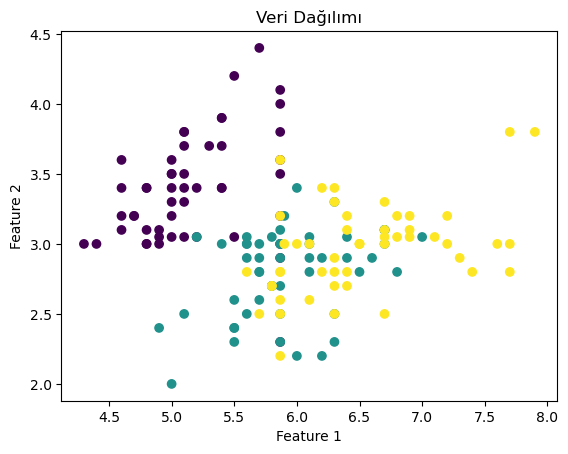

In [12]:
plt.scatter(X_clean.iloc[:, 0], X_clean.iloc[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Veri Dağılımı")
plt.show()

In [ ]:
Standardizasyon ve normalizasyon karşılaştırıldığında genellikle
Standardizasyon daha stabil sonuç verir
SVM ölçeklenmiş veride daha iyi çalışır
Modelin doğruluk oranı yüksek çıkmışttıtır bu da SVMin  bu veri setinde başarılı olduğunu gösterir
Overfitting gözlenmemiştir çünkü test verisinde de yüksek başarı elde edilmiştir